In [2]:
import dataset_prov as ds  # aataset.py but it also gives the cubelet id, if asked
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# Primary Only
ds_primary = ds.build_dataset("../Data/PrimaryOnly/Uniform", max_files=100, primary_only=True, target=["energy", "cublet"])

data_p = np.array([d[1] for d in ds_primary])

p_energy = data_p[:, 0]
p_ids    = data_p[:, 1].astype(int)

# Coordenadas Primary
p_z = p_ids // 100
p_y = (p_ids % 100) // 10
p_x = p_ids % 10


# All data
ds_all = ds.build_dataset("../Data/All", max_files=20, primary_only=False, target=["energy", "cublet","primary"])
data_a = np.array([d[1] for d in ds_all])

# Variables con prefijo 'a_' (All)
a_energy = data_a[:, 0]
a_ids    = data_a[:, 1].astype(int)

# Coordenadas All
a_z = a_ids // 100
a_y = (a_ids % 100) // 10
a_x = a_ids % 10

print(f"Primary Events: {len(p_ids)} | All Events: {len(a_ids)}")

In [11]:
print(len(ds_primary))

14942


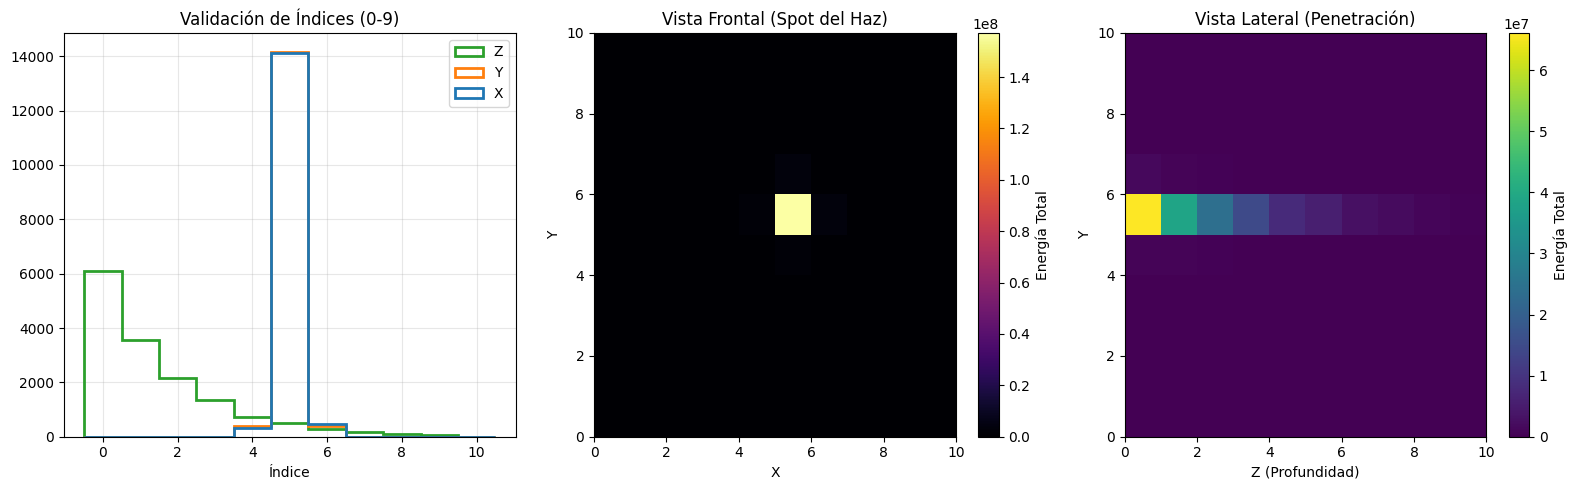

In [30]:
fig = plt.figure(figsize=(16, 5))

# 1. Validación de Índices
ax1 = fig.add_subplot(1, 3, 1)
ax1.hist([p_x, p_y, p_z], bins=np.arange(0, 12)-0.5, label=['X', 'Y', 'Z'], 
         histtype='step', linewidth=2, density=False)
ax1.set_title("Validación de Índices (0-9)")
ax1.set_xlabel("Índice"); ax1.legend(); ax1.grid(alpha=0.3)

# 2. Vista Frontal (X vs Y)
ax2 = fig.add_subplot(1, 3, 2)
h2 = ax2.hist2d(p_x, p_y, weights=p_energy, bins=[np.arange(11), np.arange(11)], cmap='inferno')
fig.colorbar(h2[3], ax=ax2, label='Energía Total')
ax2.set_title("Vista Frontal (Spot del Haz)")
ax2.set_xlabel("X"); ax2.set_ylabel("Y")

# 3. Vista Lateral (Z vs Y)
ax3 = fig.add_subplot(1, 3, 3)
h3 = ax3.hist2d(p_z, p_y, weights=p_energy, bins=[np.arange(11), np.arange(11)], cmap='viridis')
fig.colorbar(h3[3], ax=ax3, label='Energía Total')
ax3.set_title("Vista Lateral (Penetración)")
ax3.set_xlabel("Z (Profundidad)"); ax3.set_ylabel("Y")

plt.tight_layout()
plt.show()

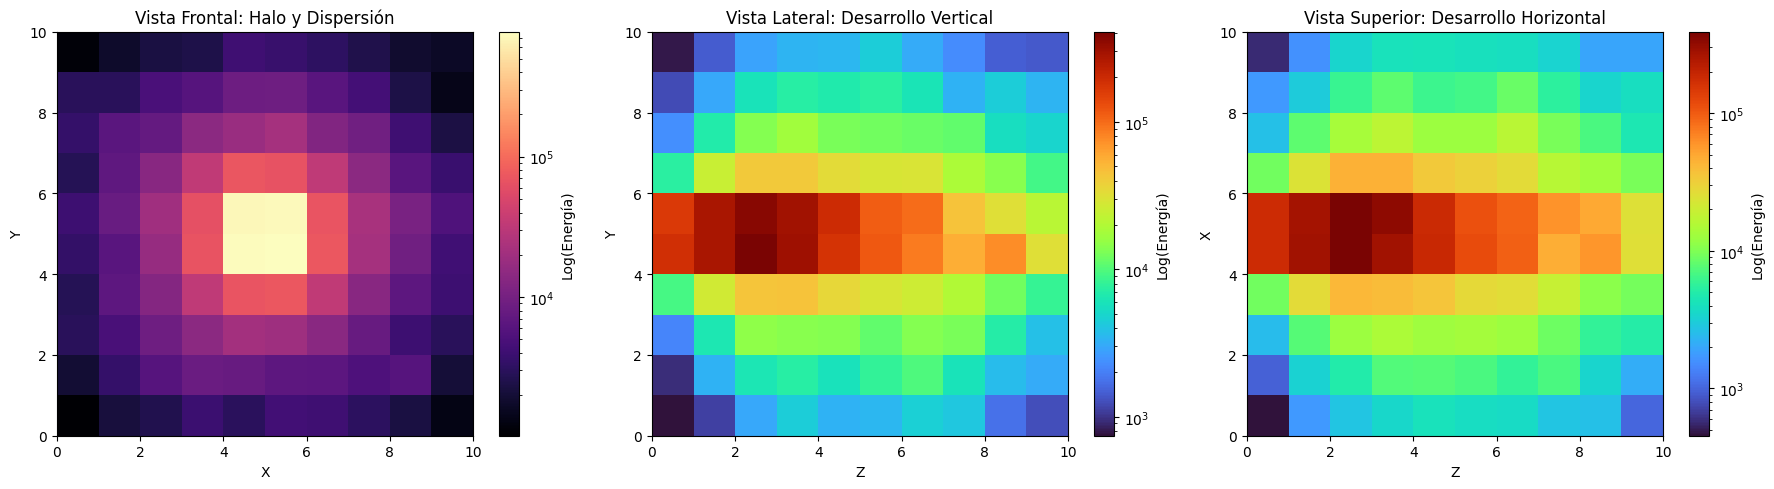

In [32]:
fig = plt.figure(figsize=(18, 5))

# 1. Vista Frontal
ax1 = fig.add_subplot(1, 3, 1)
h1 = ax1.hist2d(a_x, a_y, weights=a_energy, bins=[np.arange(11), np.arange(11)], 
                cmap='magma', norm=LogNorm()) 
fig.colorbar(h1[3], ax=ax1, label='Log(Energía)')
ax1.set_title("Vista Frontal")
ax1.set_xlabel("X"); ax1.set_ylabel("Y")

# 2. Vista Lateral
ax2 = fig.add_subplot(1, 3, 2)
h2 = ax2.hist2d(a_z, a_y, weights=a_energy, bins=[np.arange(11), np.arange(11)], 
                cmap='turbo', norm=LogNorm())
fig.colorbar(h2[3], ax=ax2, label='Log(Energía)')
ax2.set_title("Vista Lateral: Desarrollo Vertical")
ax2.set_xlabel("Z"); ax2.set_ylabel("Y")

# 3. Vista Superior
ax3 = fig.add_subplot(1, 3, 3)
h3 = ax3.hist2d(a_z, a_x, weights=a_energy, bins=[np.arange(11), np.arange(11)], 
                cmap='turbo', norm=LogNorm())
fig.colorbar(h3[3], ax=ax3, label='Log(Energía)')
ax3.set_title("Vista Superior: Desarrollo Horizontal")
ax3.set_xlabel("Z"); ax3.set_ylabel("X")

plt.tight_layout()
plt.show()

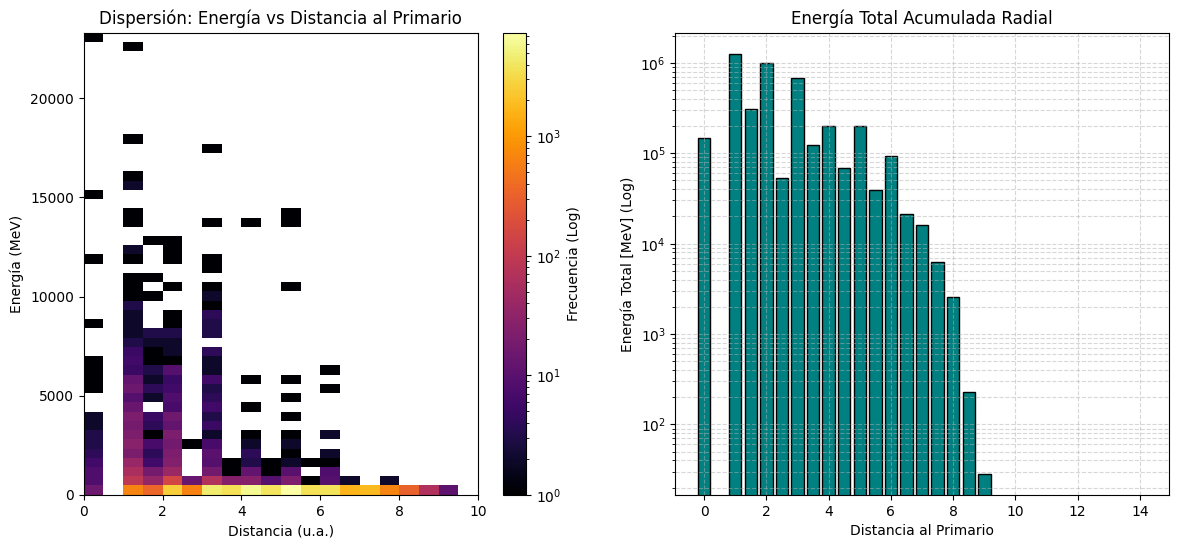

In [33]:
fig = plt.figure(figsize=(14, 6))

# 1. Mapa de Calor (Energía vs Distancia)
ax1 = fig.add_subplot(1, 2, 1)
h = ax1.hist2d(a_distances, a_energy, bins=[20, 50], range=[[0, 10], [0, a_energy.max()]], 
               cmap='inferno', norm=LogNorm())
fig.colorbar(h[3], ax=ax1, label='Frecuencia (Log)')
ax1.set_title("Dispersión: Energía vs Distancia al Primario")
ax1.set_xlabel("Distancia (u.a.)"); ax1.set_ylabel("Energía (MeV)")

# 2. Energía Acumulada por Distancia
bins_dist = np.arange(0, 15, 0.5)
digitized = np.digitize(a_distances, bins_dist)
energy_per_distance = [a_energy[digitized == i].sum() for i in range(1, len(bins_dist))]

ax2 = fig.add_subplot(1, 2, 2)
ax2.bar(bins_dist[:-1], energy_per_distance, width=0.4, color='teal', edgecolor='black')
ax2.set_title("Energía Total Acumulada Radial")
ax2.set_xlabel("Distancia al Primario")
ax2.set_ylabel("Energía Total [MeV] (Log)")
ax2.set_yscale('log')
ax2.grid(True, which="both", linestyle='--', alpha=0.5)

plt.show()

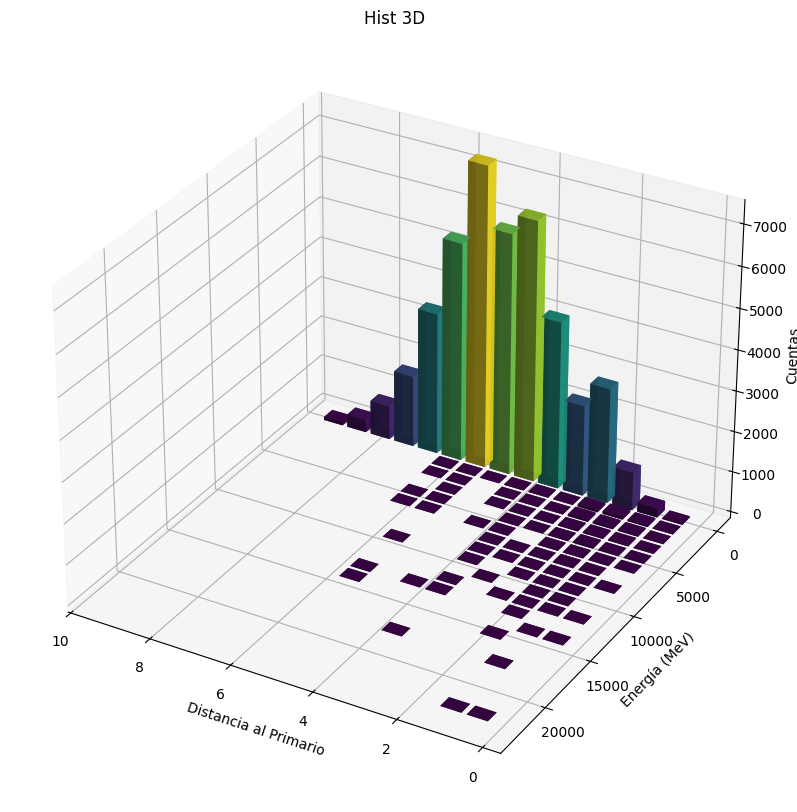

In [41]:
# Preparación de datos 3D
bins_d = 15
bins_e = 20

hist, x_edges, y_edges = np.histogram2d(a_distances, a_energy, bins=[bins_d, bins_e])

# Malla
xpos, ypos = np.meshgrid(x_edges[:-1] + 0.25, y_edges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos) # Base en 0

# Dimensiones de las barras
dx = np.ones_like(zpos) * (x_edges[1] - x_edges[0]) * 0.8
dy = np.ones_like(zpos) * (y_edges[1] - y_edges[0]) * 0.8
dz = hist.ravel() # Altura = Cuentas

# Filtro de ceros (Máscara)
mask = dz > 0
xpos_f, ypos_f, zpos_f = xpos[mask], ypos[mask], zpos[mask]
dx_f, dy_f, dz_f = dx[mask], dy[mask], dz[mask]

# Plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

colores = plt.cm.viridis(dz_f / dz_f.max())

ax.bar3d(xpos_f, ypos_f, zpos_f, dx_f, dy_f, dz_f, color=colores, zsort='average', alpha=0.9)

ax.set_xlabel('Distancia al Primario')
ax.set_ylabel('Energía (MeV)')
ax.set_zlabel('Cuentas')
ax.set_title('Hist 3D')

# ax.view_init(elev=30, azim=-60) 


# ax.view_init(elev=10, azim=-80)


# ax.view_init(elev=80, azim=-90)


ax.view_init(elev=30, azim=120)

plt.show()


plt.show()

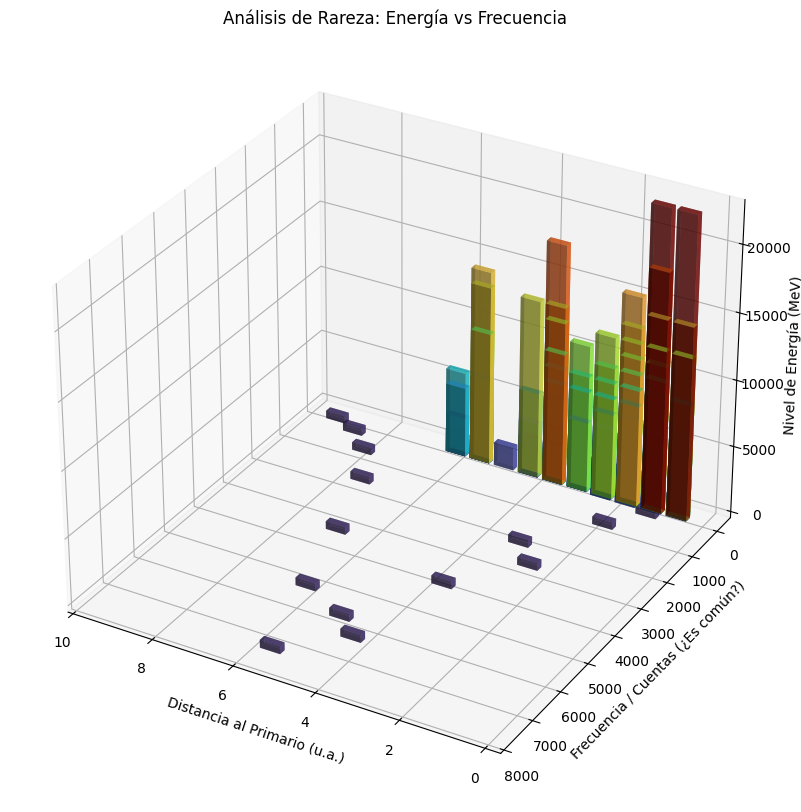

In [44]:
# 2. Generamos el Histograma base para obtener los datos
bins_d = 15 # Resolución de distancia
bins_e = 20 # Resolución de energía

# Obtenemos la matriz de frecuencias (Counts)
counts_matrix, dist_edges, ener_edges = np.histogram2d(a_distances, a_energy, bins=[bins_d, bins_e])

# Centros de los bins de distancia y energía
dist_centers = (dist_edges[:-1] + dist_edges[1:]) / 2
ener_centers = (ener_edges[:-1] + ener_edges[1:]) / 2

# Creamos mallas para recorrer todas las combinaciones
D, E = np.meshgrid(dist_centers, ener_centers, indexing='ij')

# Aplanamos todo para pasarlo a bar3d
x_vals = D.ravel()        # Distancia
z_heights = E.ravel()     # Energía (Esta será la ALTURA)
y_counts = counts_matrix.ravel() # Cuentas (Esto será el EJE Y)

# 4. Filtrado y Dimensiones
# Solo graficamos donde hay datos (cuentas > 0)
mask = y_counts > 0

xpos = x_vals[mask]
ypos = y_counts[mask]     # La posición en Y es cuántas veces ocurrió
zpos = np.zeros_like(xpos) # Las barras nacen del suelo (Z=0)

# Dimensiones de las barras
dx = np.ones_like(xpos) * (dist_edges[1] - dist_edges[0]) * 0.8
dy = np.ones_like(xpos) * (y_counts.max() * 0.02) # Hacemos las barras finas en Y para que no se pisen
dz = z_heights[mask]      # La altura es la Energía

# 5. Plot 3D Invertido
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Coloreamos por Energía (Altura)
colores = plt.cm.turbo(dz / dz.max())

# Usamos alpha=0.6 porque puede haber barras solapadas
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colores, zsort='average', alpha=0.6)

ax.set_xlabel('Distancia al Primario (u.a.)')
ax.set_ylabel('Frecuencia / Cuentas (¿Es común?)')
ax.set_zlabel('Nivel de Energía (MeV)') # <--- AHORA Z ES ENERGÍA

ax.set_title('Análisis de Rareza: Energía vs Frecuencia')

# Vista sugerida para ver la relación rareza-energía
# ax.view_init(elev=20, azim=-45)
ax.view_init(elev=30, azim=120)

plt.show()